In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)

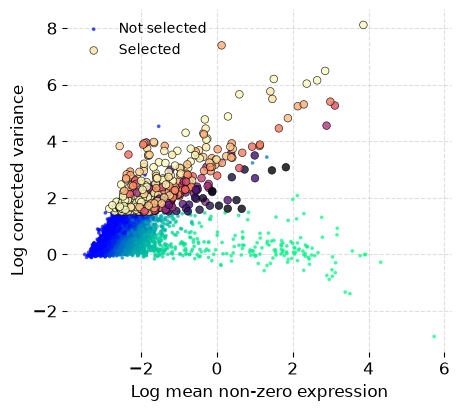

In [2]:
ds.filter_cells(attrs=['RNA_nCounts'], highs=[15000], lows=[1000], reset_previous=True)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15)
ds.run_umap(n_epochs=150, parallel=True)

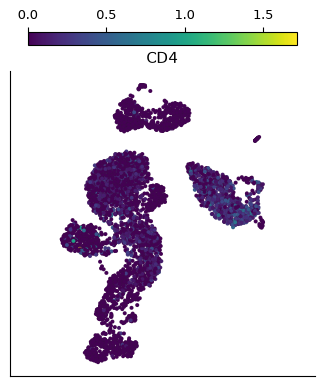

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [3]:
imputed_cd4 = ds.get_imputed(feature_name='CD4', t=2)
ds.cells.insert('CD4_imputed', imputed_cd4, overwrite=True)
splt.embedding(ds, layout_key='RNA_UMAP', color_by='CD4')

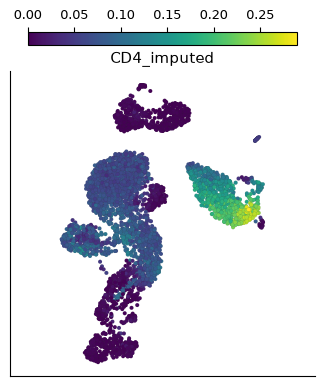

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [4]:
splt.embedding(ds, layout_key='RNA_UMAP', color_by='CD4_imputed')